In [ ]:
# pip install statsmodels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
DATA_PATH = 'datasets/ice_cream.csv'
TARGET_COL = 'IPN31152N'
DATE_COL = 'DATE'

df = pd.read_csv(DATA_PATH)
df.head()

,DATE,IPN31152N
0,1972-01-01,59.9622
1,1972-02-01,67.0605
2,1972-03-01,74.2350
3,1972-04-01,78.1120
4,1972-05-01,84.7636


In [ ]:
ts_df = df.copy()
ts_df[DATE_COL] = pd.to_datetime(ts_df[DATE_COL])
ts_df[TARGET_COL] = pd.to_numeric(ts_df[TARGET_COL], errors='coerce')
ts_df = ts_df.sort_values(DATE_COL).set_index(DATE_COL)

ts_df = ts_df.asfreq('MS')

ts_df.head()

,IPN31152N
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636


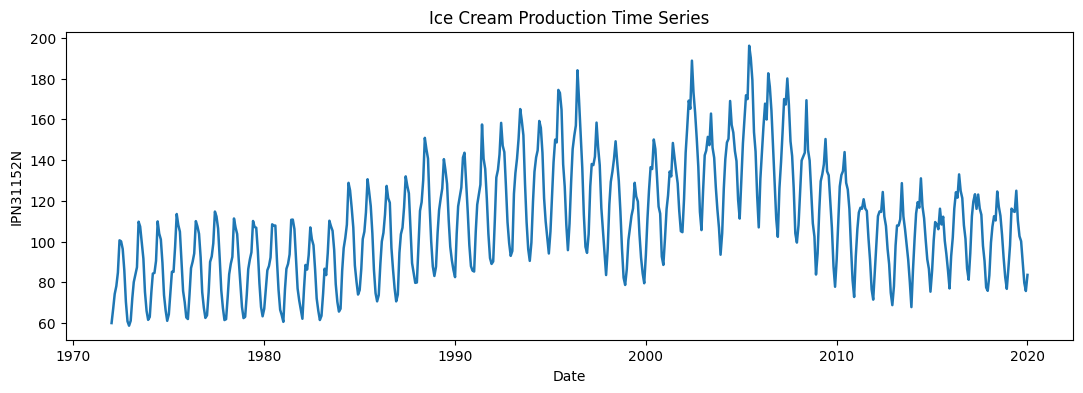

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts_df.index, ts_df[TARGET_COL], color='tab:blue', linewidth=1.8)
ax.set_title('Ice Cream Production Time Series')
ax.set_xlabel('Date')
ax.set_ylabel(TARGET_COL)
plt.show()

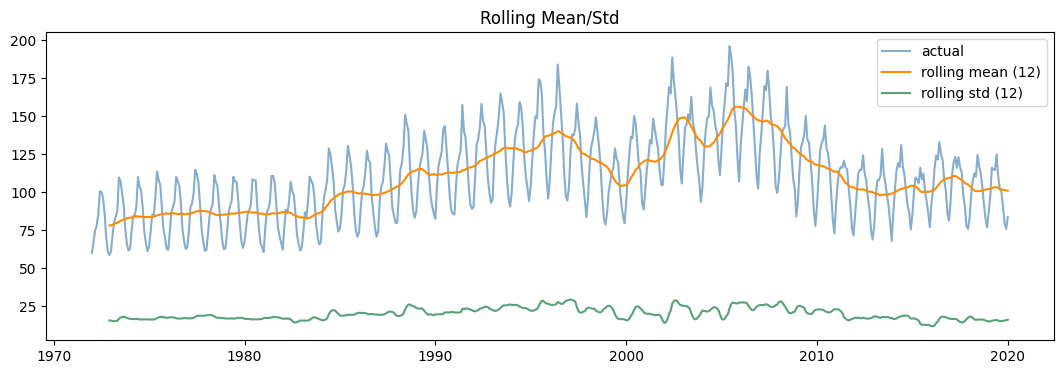

In [ ]:
ts_df['roll_mean_12'] = ts_df[TARGET_COL].rolling(window=12).mean()
ts_df['roll_std_12'] = ts_df[TARGET_COL].rolling(window=12).std()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts_df.index, ts_df[TARGET_COL], label='actual', color='steelblue', alpha=0.65)
ax.plot(ts_df.index, ts_df['roll_mean_12'], label='rolling mean (12)', color='darkorange')
ax.plot(ts_df.index, ts_df['roll_std_12'], label='rolling std (12)', color='seagreen', alpha=0.8)
ax.set_title('Rolling Mean/Std')
ax.legend()
plt.show()

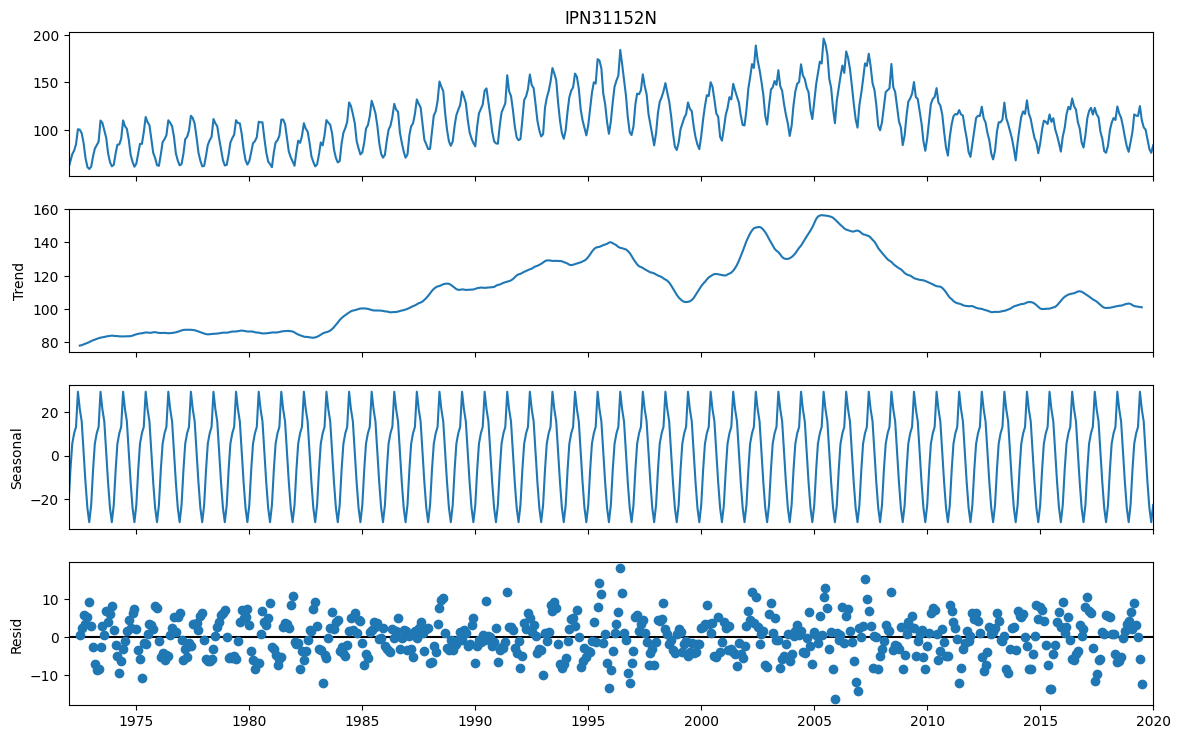

In [ ]:
decomp = seasonal_decompose(ts_df[TARGET_COL].dropna(), model='additive', period=12)
decomp.plot()
plt.gcf().set_size_inches(13, 8)
plt.show()

In [ ]:
n = len(ts_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = ts_df.iloc[:train_end][TARGET_COL].copy()
val = ts_df.iloc[train_end:val_end][TARGET_COL].copy()
test = ts_df.iloc[val_end:][TARGET_COL].copy()

print('Train:', train.index.min().date(), '->', train.index.max().date(), 'len =', len(train))
print('Validation:', val.index.min().date(), '->', val.index.max().date(), 'len =', len(val))
print('Test:', test.index.min().date(), '->', test.index.max().date(), 'len =', len(test))

Train: 1972-01-01 -> 2005-07-01 len = 403
Validation: 2005-08-01 -> 2012-10-01 len = 87
Test: 2012-11-01 -> 2020-01-01 len = 87


In [ ]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    non_zero = y_true != 0
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

def evaluate_forecast(name, y_true, y_pred):
    return {
        'model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'MAPE_%': mape(y_true, y_pred)
    }

In [9]:
# Baseline 1: Naive (последнее значение train+val)
history = pd.concat([train, val])
naive_pred = pd.Series(history.iloc[-1], index=test.index)

# Baseline 2: Moving average (последние 12 наблюдений history)
ma12_value = history.tail(12).mean()
ma12_pred = pd.Series(ma12_value, index=test.index)

# Baseline 3: Seasonal naive (значение того же месяца прошлого года)
seasonal_naive_pred = history.reindex(test.index - pd.DateOffset(years=1)).set_axis(test.index)

results = []
results.append(evaluate_forecast('Naive', test, naive_pred))
results.append(evaluate_forecast('MovingAvg_12', test, ma12_pred))
results.append(evaluate_forecast('SeasonalNaive_12m', test, seasonal_naive_pred))

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

ValueError: Input contains NaN.

## ARIMA

ARIMA - это классическая модель для рядов с трендом, но без явной сложной сезонности.

Идея модели:
- p: сколько прошлых значений используем
- d: сколько раз делаем differencing
- q: сколько прошлых ошибок учитываем

На практике важно помнить:
- ARIMA хорошо показывает сам принцип прогнозирования
- для ярко выраженной сезонности часто нужен SARIMA
- если baseline лучше ARIMA, это тоже полезный результат для анализа

In [ ]:
# ARIMA example
# Для monthly series берем простую классическую модель без сезонного компонента
arima_order = (2, 1, 2)
arima_model = ARIMA(
    history,
    order=arima_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_fit = arima_model.fit()
arima_pred = pd.Series(arima_fit.forecast(steps=len(test)), index=test.index)

arima_result = evaluate_forecast(f'ARIMA_{arima_order}', test, arima_pred)
results_with_arima = pd.concat([results_df, pd.DataFrame([arima_result])], ignore_index=True).sort_values('RMSE').reset_index(drop=True)

print(f'ARIMA order: {arima_order}')
print(f'AIC: {arima_fit.aic:.2f}')
print(f'BIC: {arima_fit.bic:.2f}')
results_with_arima

ARIMA order: (2, 1, 2)
AIC: 3295.17
BIC: 3316.10


,model,MAE,RMSE,MAPE_%
0,"ARIMA_(2, 1, 2)",7.144238,8.779244,7.076755
1,MovingAvg_12,13.856760,16.218983,14.202130
2,Naive,17.755340,20.826260,16.532409


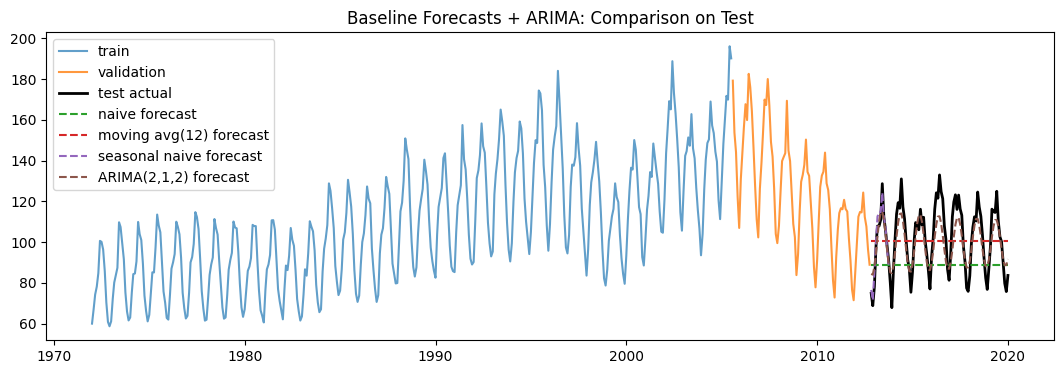

In [ ]:
# Визуальное сравнение baseline-прогнозов
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index, train.values, label='train', alpha=0.7)
ax.plot(val.index, val.values, label='validation', alpha=0.8)
ax.plot(test.index, test.values, label='test actual', color='black', linewidth=2)
ax.plot(test.index, naive_pred.values, label='naive forecast', linestyle='--')
ax.plot(test.index, ma12_pred.values, label='moving avg(12) forecast', linestyle='--')
ax.plot(test.index, seasonal_naive_pred.values, label='seasonal naive forecast', linestyle='--')
ax.plot(test.index, arima_pred.values, label='ARIMA(2,1,2) forecast', linestyle='--')
ax.set_title('Baseline Forecasts + ARIMA: Comparison on Test')
ax.legend(loc='best')
plt.show()

## Ссылка на источники данных: 
https://fred.stlouisfed.org/